In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('gdrive/My Drive/Colab Notebooks/tableau_data_sample.csv')
#clean up data
#columns that do not help affect/help prediction are dropped
df = df.drop(columns=['satellite', 'instrument', 'version', 'acq_date', 'acq_time'])

#assign numbers to labels
df['daynight'] = df['daynight'].map({'D': 0, 'N': 1})
df['confidence'] = df['confidence'].map({'l': 0, 'n': 1, 'h': 2})

#data split
X = df.drop('type', axis=1)
y = df['type']
#add validation split 70 20 - validation 10 - test
#split off the Test set
#remaining 90% goes into X_temp and y_temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

#split the 90% temp data into train and validation
# test_size=0.222 roughly calculates to 20% of the original 100%
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.222, random_state=42)

Mounted at /content/gdrive


In [4]:
#random forest classifier (initially fixed from logistic regression to look at
#balance) creating the pipeline
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'  #gives the rare types of fire more importance
    ))
])

In [5]:
#train model
model_pipeline.fit(X_train, y_train)

#validation
val_predictions = model_pipeline.predict(X_val)
print(classification_report(y_val, val_predictions))

#make predictions
#goal is for model to predict the type of the fire accurately
y_pred = model_pipeline.predict(X_test)

#show results on how much model (types/categories of fire) predicted correctly
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7495
           1       0.00      0.00      0.00         7
           2       0.78      0.55      0.65       440
           3       0.00      0.00      0.00        50

    accuracy                           0.96      7992
   macro avg       0.44      0.39      0.41      7992
weighted avg       0.95      0.96      0.96      7992

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3757
           1       0.00      0.00      0.00         3
           2       0.76      0.53      0.63       214
           3       1.00      0.04      0.07        26

    accuracy                           0.96      4000
   macro avg       0.68      0.39      0.42      4000
weighted avg       0.96      0.96      0.95      4000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [6]:
#show results
print(confusion_matrix(y_test, y_pred))

[[3728    0   29    0]
 [   3    0    0    0]
 [ 100    0  114    0]
 [  18    0    7    1]]


In [7]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy Score: {dummy.score(X_test, y_test):.2f}")

Dummy Accuracy Score: 0.94


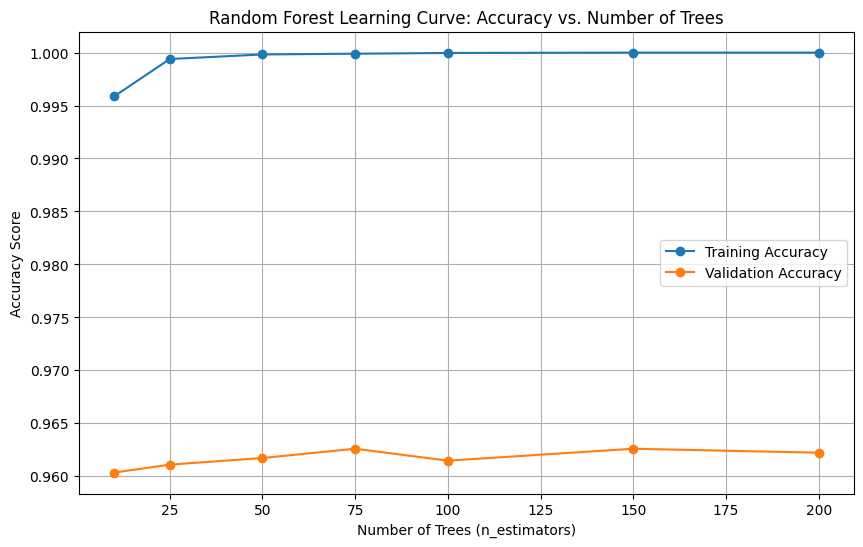

In [8]:
#loss and accuracy curves
import matplotlib.pyplot as plt
import numpy as np

# 1. Define a range of trees to test
tree_counts = [10, 25, 50, 75, 100, 150, 200]
train_scores = []
val_scores = []

# 2. Iterate through tree counts to "record" learning progress
for n in tree_counts:
    # Update the classifier in the pipeline
    model_pipeline.set_params(classifier__n_estimators=n)
    model_pipeline.fit(X_train, y_train)

    # Record accuracy for Training and Validation sets
    train_scores.append(model_pipeline.score(X_train, y_train))
    val_scores.append(model_pipeline.score(X_val, y_val))

# 3. Create the Accuracy Curve Plot
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, train_scores, label='Training Accuracy', marker='o')
plt.plot(tree_counts, val_scores, label='Validation Accuracy', marker='o')

plt.title('Random Forest Learning Curve: Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)
plt.show()

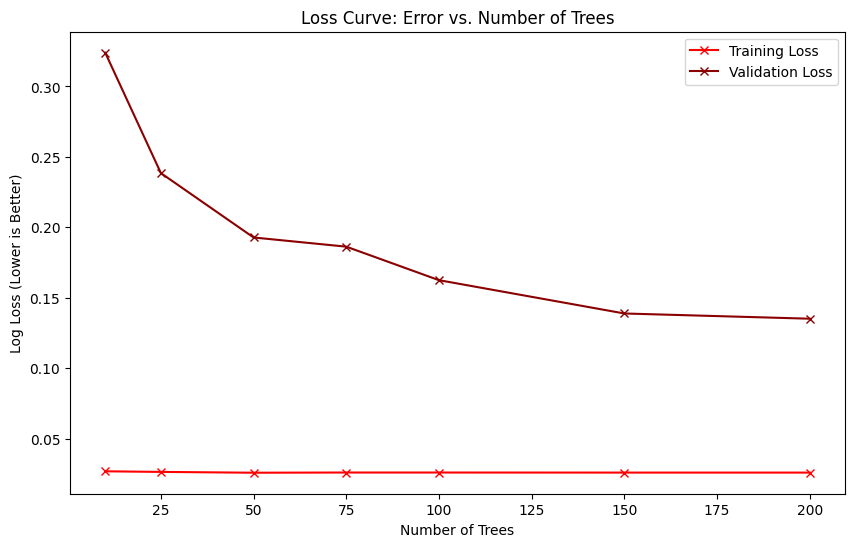

In [9]:
from sklearn.metrics import log_loss

train_losses = []
val_losses = []

for n in tree_counts:
    model_pipeline.set_params(classifier__n_estimators=n)
    model_pipeline.fit(X_train, y_train)

    # Get probability predictions instead of hard classes
    train_probs = model_pipeline.predict_proba(X_train)
    val_probs = model_pipeline.predict_proba(X_val)

    train_losses.append(log_loss(y_train, train_probs))
    val_losses.append(log_loss(y_val, val_probs))

# Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, train_losses, label='Training Loss', color='red', marker='x')
plt.plot(tree_counts, val_losses, label='Validation Loss', color='darkred', marker='x')
plt.title('Loss Curve: Error vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss (Lower is Better)')
plt.legend()
plt.show()

In [10]:
#logistic regression model starts here
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), #fills missing fire data
    ('scaler', StandardScaler()),                 #for Logistic Regression math
    ('classifier', LogisticRegression(
        max_iter=1000,                            #ensures the model has time to find the best fit
        random_state=42,
        class_weight='balanced',                  #for model to care about rare fire types
        multi_class='multinomial'                 #handles multiple fire categories
    ))
])

In [11]:
lr_pipeline.fit(X_train, y_train)

print(classification_report(y_val, lr_pipeline.predict(X_val)))

y_pred = lr_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.99      0.70      0.82      7495
           1       0.00      0.57      0.01         7
           2       0.24      0.55      0.33       440
           3       0.03      0.32      0.05        50

    accuracy                           0.69      7992
   macro avg       0.31      0.54      0.30      7992
weighted avg       0.94      0.69      0.78      7992

              precision    recall  f1-score   support

           0       0.99      0.68      0.80      3757
           1       0.00      0.33      0.00         3
           2       0.24      0.57      0.34       214
           3       0.03      0.42      0.06        26

    accuracy                           0.67      4000
   macro avg       0.32      0.50      0.30      4000
weighted avg       0.94      0.67      0.77      4000



In [12]:
print(confusion_matrix(y_test, y_pred))

[[2545  553  372  287]
 [   1    1    1    0]
 [  23   21  121   49]
 [   1    7    7   11]]


In [13]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy Score: {dummy.score(X_test, y_test):.2f}")

Dummy Accuracy Score: 0.94


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

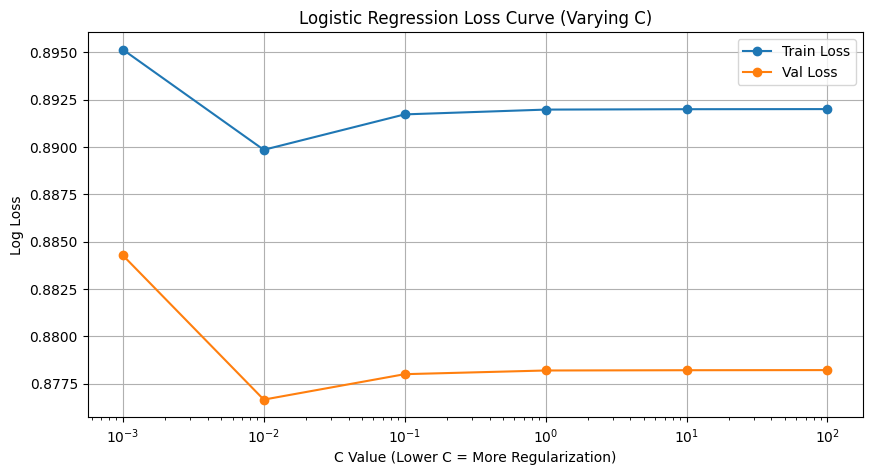

In [14]:
#loss curces
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_losses = []
val_losses = []

for c in c_values:
    lr_pipeline.set_params(classifier__C=c)
    lr_pipeline.fit(X_train, y_train)

    train_losses.append(log_loss(y_train, lr_pipeline.predict_proba(X_train)))
    val_losses.append(log_loss(y_val, lr_pipeline.predict_proba(X_val)))

# Plotting the Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(c_values, train_losses, label='Train Loss', marker='o')
plt.plot(c_values, val_losses, label='Val Loss', marker='o')
plt.xscale('log') # C values span multiple orders of magnitude
plt.title('Logistic Regression Loss Curve (Varying C)')
plt.xlabel('C Value (Lower C = More Regularization)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
#apply log transformation to frp to handle extreme outliers
#avoid issues if any frp value is 0
df['frp'] = np.log1p(df['frp'])

In [16]:
#looking at frp weight
features = X.columns
weights = lr_pipeline.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({'Feature': features, 'Weight': weights})
print(feature_importance.sort_values(by='Weight', ascending=False))

      Feature    Weight
7         frp  0.408397
6  bright_t31  0.255014
4       track  0.108538
1   longitude  0.099362
3        scan -0.026796
5  confidence -0.307547
2  brightness -0.330329
0    latitude -0.591755
8    daynight -0.915933


In [17]:
#brightness to bright_t31 ratio
df['brightness_ratio'] = df['brightness'] / df['bright_t31']
print(df[['brightness', 'bright_t31', 'brightness_ratio']].head())

   brightness  bright_t31  brightness_ratio
0      337.79      307.17          1.099684
1      303.67      283.56          1.070920
2      346.01      305.26          1.133493
3      343.84      303.73          1.132058
4      339.18      310.37          1.092825
